![lop](../../images/logo_diive1_128px.png)

<span style='font-size:32px; display:block;'>
<b>
    Outlier detection: Hampel filter, separately for daytime and nighttime data
</b>
</span>

---
**Notebook version**: `3` (13 Jan 2026)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)  

</br>

# **Description**

- Identify outliers in a sliding window based on the Hampel filter, separately for daytime and nighttime data.
- The Hampel filter employs a moving window and utilizes the Median Absolute Deviation (MAD) as a measure of data variability. MAD is calculated by taking the median of the absolute differences between each data point and the median of the moving window.
- Implemented from [sktime](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.transformations.series.outlier_detection.HampelFilter.html)
- Flag contains `0` and `2`, whereby `0=OK` and `2=outlier`
- This example uses air temperature for one month and adds impulse noise to add some spikes to the data before testing

</br>

# **Imports**

In [1]:
import importlib.metadata
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd

import diive.configs.exampledata as ed
from diive.core.plotting.timeseries import TimeSeries
from diive.pkgs.createvar.noise import add_impulse_noise
from diive.pkgs.outlierdetection.hampel import HampelDaytimeNighttime

warnings.filterwarnings('ignore')
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.90.0


</br>

# **Docstring**

In [2]:
help(HampelDaytimeNighttime)
print(HampelDaytimeNighttime.__init__.__doc__)

Help on function HampelDaytimeNighttime in module diive.pkgs.outlierdetection.hampel:

HampelDaytimeNighttime(series: pandas.core.series.Series, lat: float = None, lon: float = None, utc_offset: int = None, window_length: int = 13, n_sigma_dt: float = 5.5, n_sigma_nt: float = 5.5, k: float = 1.4826, use_differencing: bool = True, separate_day_night: bool = True, idstr: str = None, showplot: bool = False, verbose: bool = False)


        Identify outliers using the Hampel filter (Median Absolute Deviation).

        This class implements a robust outlier detection algorithm. It is designed to handle
        ecological time series (like Eddy Covariance data) by offering two advanced modes:

        1. **Papale Method (FLUXNET Standard):** If ``use_differencing=True``, the filter is
           applied to the double-differenced time series ($d = (x_t - x_{t-1}) - (x_{t+1} - x_t)$).
           This removes biological trends (e.g., morning temperature rise) and isolates
           short-term

</br>

# **Load example data**

## Load and prepare data (one month)

In [25]:
df, _ = ed.load_exampledata_EDDYPRO_FLUXNET_CSV_30MIN()
s = df['FC'].copy()
s

Reading file exampledata_EDDYPRO-FLUXNET-CSV-30MIN_CH-AWS_2022.07_FR-20220127-164245_eddypro_fluxnet_2022-01-28T112538_adv.csv ...


TIMESTAMP_MIDDLE
2021-07-01 00:15:00    20.97900
2021-07-01 00:45:00    18.49270
2021-07-01 01:15:00    18.42820
2021-07-01 01:45:00    15.42470
2021-07-01 02:15:00    18.50180
                         ...   
2021-07-31 21:45:00     8.66570
2021-07-31 22:15:00     4.51717
2021-07-31 22:45:00     6.42054
2021-07-31 23:15:00     7.35309
2021-07-31 23:45:00     9.28661
Freq: 30min, Name: FC, Length: 1488, dtype: float64

## Test data: add impulse noise to time series, this creates spike outliers

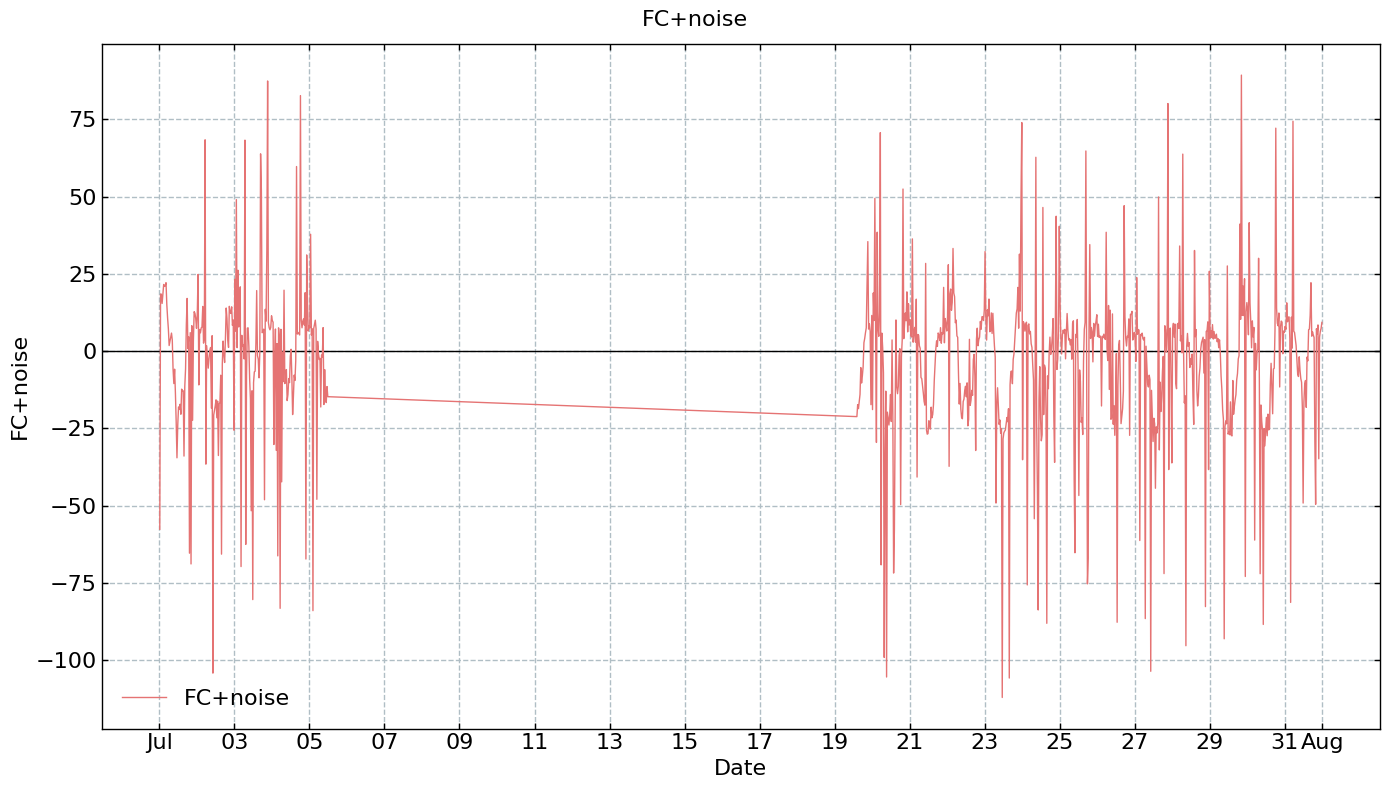

In [26]:
s_noise = add_impulse_noise(series=s,
                            factor_low=-2,
                            factor_high=2,
                            contamination=0.2)  # Add impulse noise (spikes)
s_noise.name = f"{s.name}+noise"
TimeSeries(s_noise).plot();

</br>

# **Hampel filter**

## With double-differencing, separate for daytime and nighttime data
- `use_differencing=True`
- `separate_day_night=True`, this needs latitude, longitude and utc_offset of site

[HampelDaytimeNighttime]  running HampelDaytimeNighttime ...
[Dt/Nt] ITER #01 | Outliers:    58 (  7.15%) | Day:    37 | Night:    21
[Dt/Nt] ITER #02 | Outliers:    32 (  4.25%) | Day:    18 | Night:    14
[Dt/Nt] ITER #03 | Outliers:    19 (  2.64%) | Day:    10 | Night:     9
[Dt/Nt] ITER #04 | Outliers:    13 (  1.85%) | Day:     6 | Night:     7
[Dt/Nt] ITER #05 | Outliers:     2 (  0.29%) | Day:     0 | Night:     2
[Dt/Nt] ITER #06 | Outliers:     2 (  0.29%) | Day:     0 | Night:     2
[Dt/Nt] ITER #07 | Outliers:     1 (  0.15%) | Day:     0 | Night:     1
[Dt/Nt] ITER #08 | Outliers:     1 (  0.15%) | Day:     0 | Night:     1
[Dt/Nt] ITER #09 | Outliers:     1 (  0.15%) | Day:     0 | Night:     1
[Dt/Nt] ITER #10 | Outliers:     1 (  0.15%) | Day:     1 | Night:     0
[Dt/Nt] ITER #11 | Outliers:     1 (  0.15%) | Day:     1 | Night:     0
[Dt/Nt] ITER #12 | Outliers:     1 (  0.15%) | Day:     1 | Night:     0
[Dt/Nt] ITER #13 | Outliers:     1 (  0.15%) | Day:     1 | Nig

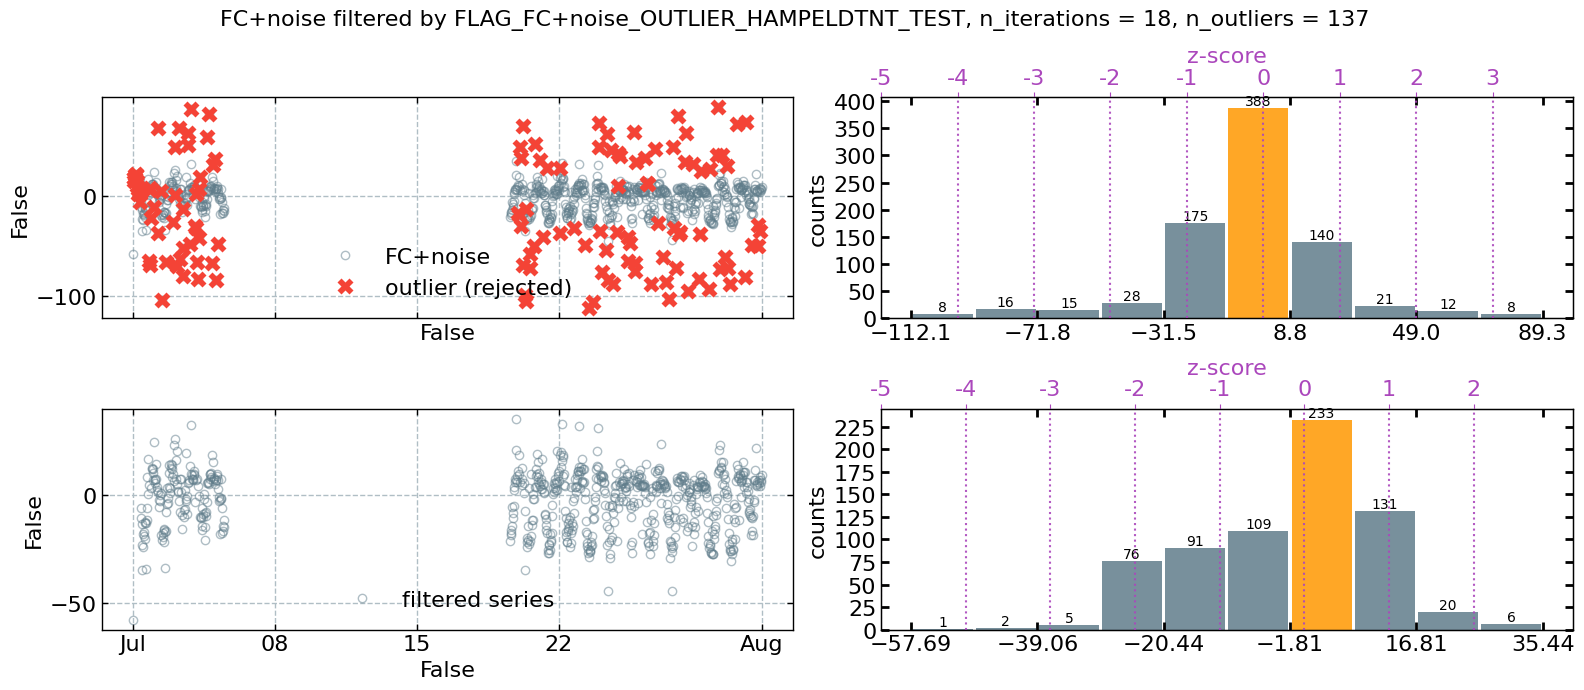

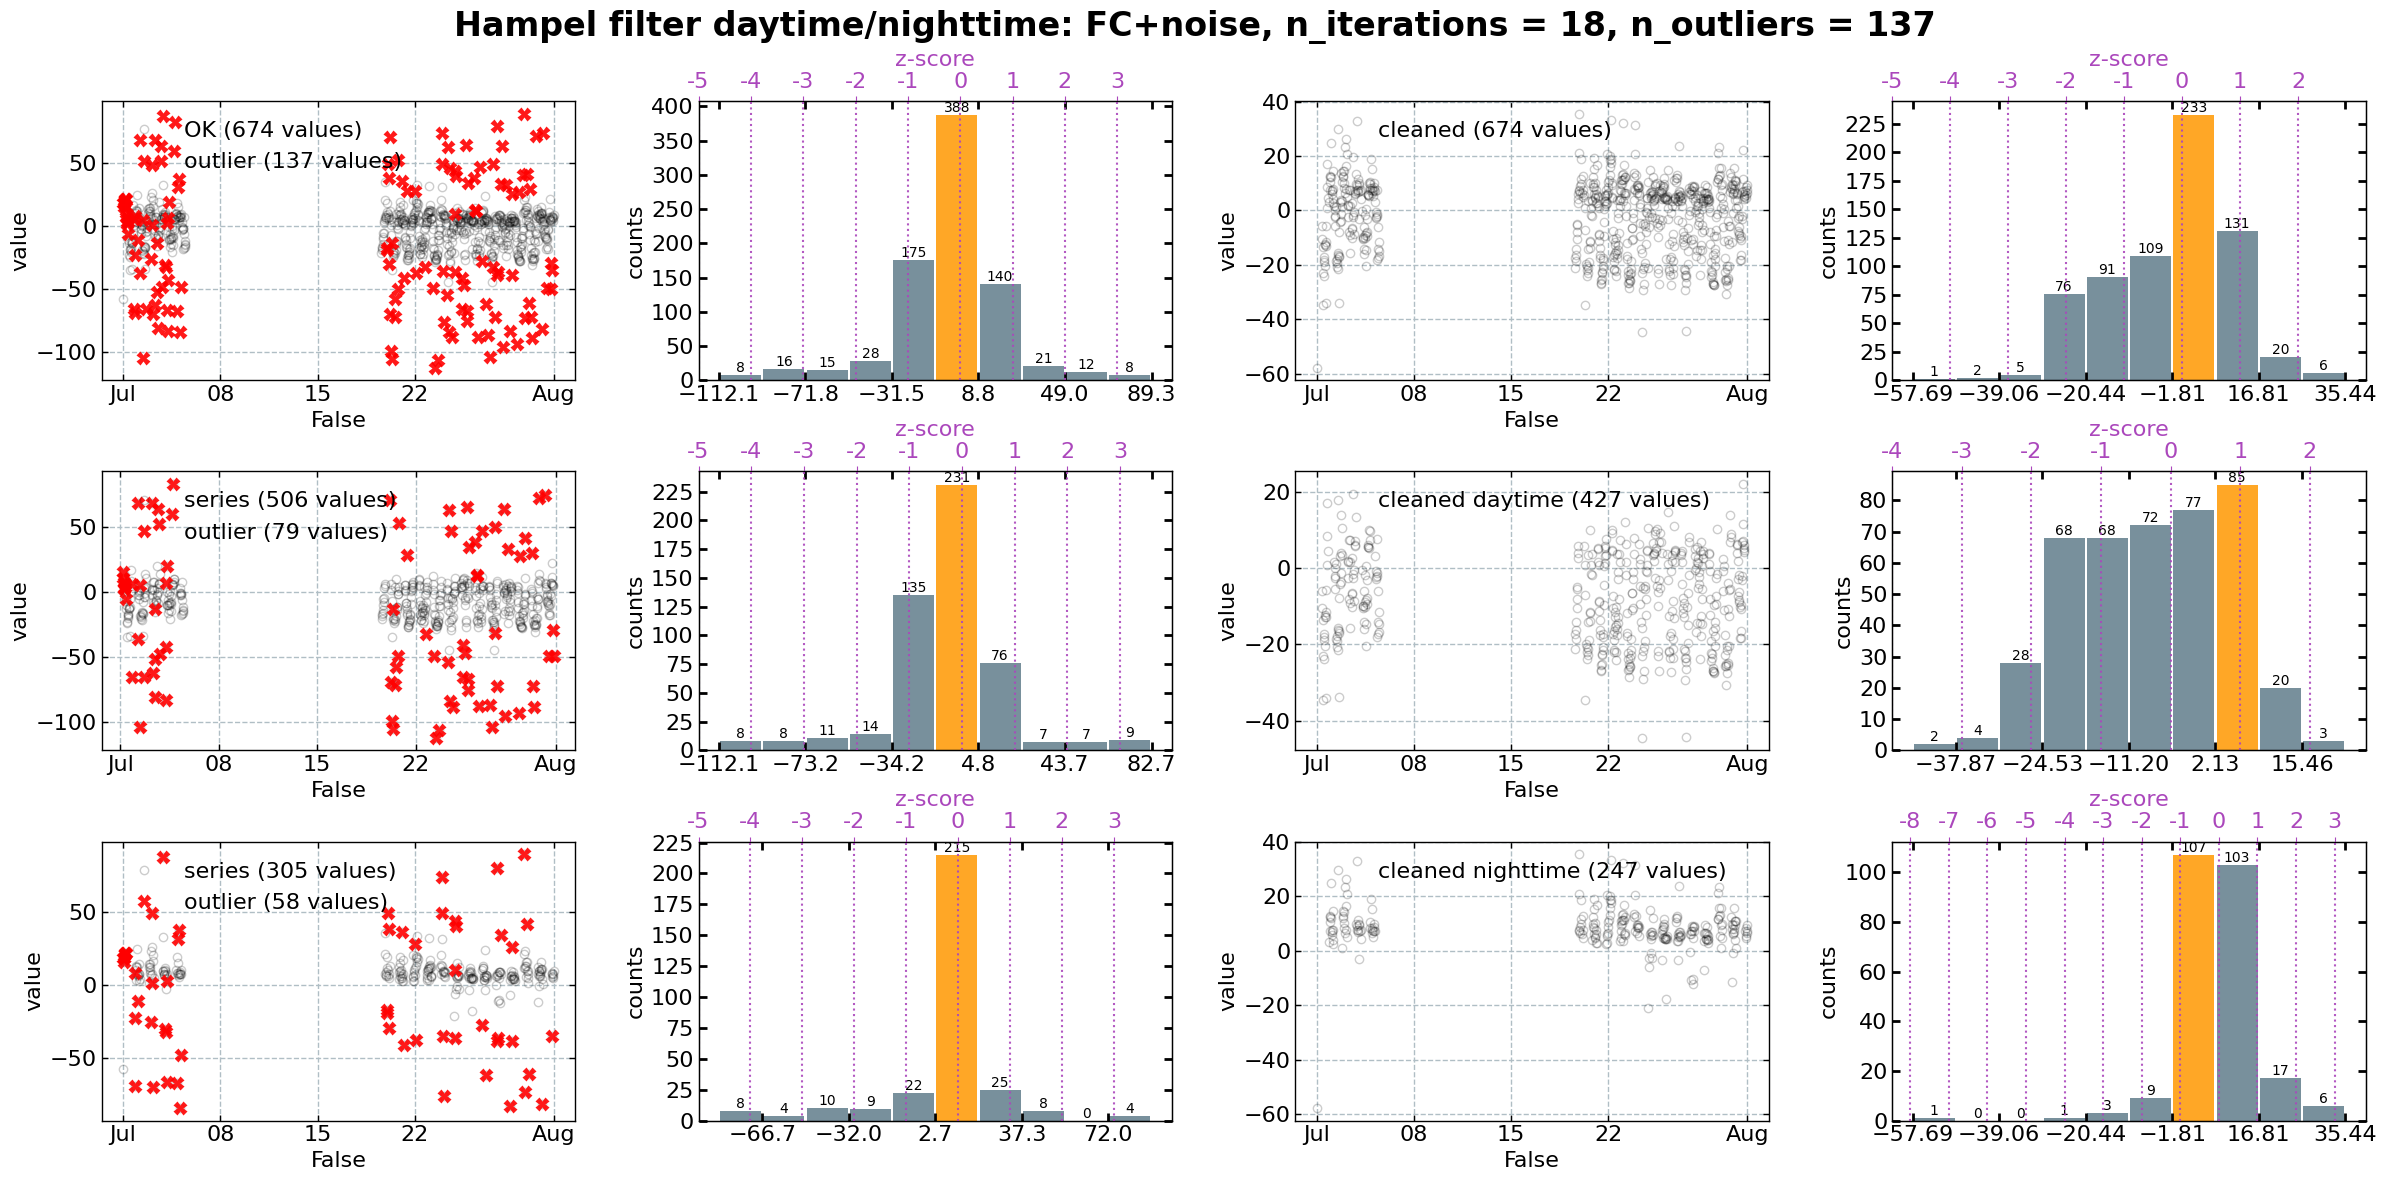

In [30]:
ham = HampelDaytimeNighttime(
    series=s_noise,
    n_sigma_dt=5.5,
    n_sigma_nt=5.5,
    window_length=48 * 13,
    use_differencing=True,
    separate_day_night=True,
    showplot=True,
    verbose=True,
    lat=47.286417,
    lon=7.733750,
    utc_offset=1
)
ham.calc(repeat=True)

In [31]:
# Get flag
flag = ham.get_flag()
flag

TIMESTAMP_MIDDLE
2021-07-01 00:15:00    0.0
2021-07-01 00:45:00    2.0
2021-07-01 01:15:00    2.0
2021-07-01 01:45:00    2.0
2021-07-01 02:15:00    2.0
                      ... 
2021-07-31 21:45:00    2.0
2021-07-31 22:15:00    0.0
2021-07-31 22:45:00    0.0
2021-07-31 23:15:00    0.0
2021-07-31 23:45:00    0.0
Freq: 30min, Name: FLAG_FC+noise_OUTLIER_HAMPELDTNT_TEST, Length: 1488, dtype: float64

In [32]:
# Combine the original series, series+noise and the outlier flag
frame = {'s': s, 's_noise': s_noise, 'flag': flag}
checkdf = pd.DataFrame.from_dict(frame)
checkdf

,s,s_noise,flag
TIMESTAMP_MIDDLE,,,
2021-07-01 00:15:00,20.97900,-57.688935,0.0
2021-07-01 00:45:00,18.49270,18.492700,2.0
2021-07-01 01:15:00,18.42820,18.428200,2.0
2021-07-01 01:45:00,15.42470,15.424700,2.0
2021-07-01 02:15:00,18.50180,18.501800,2.0
...,...,...,...
2021-07-31 21:45:00,8.66570,-34.866478,2.0
2021-07-31 22:15:00,4.51717,4.517170,0.0
2021-07-31 22:45:00,6.42054,6.420540,0.0


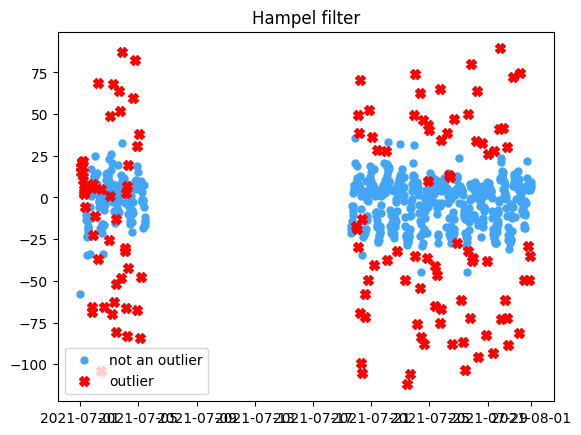

In [33]:
good_data = checkdf.loc[checkdf['flag'] == 0]['s_noise']
rejected_data = checkdf.loc[checkdf['flag'] == 2]['s_noise']

fig, ax = plt.subplots()
ax.plot(good_data, color="#42A5F5", label="not an outlier", lw=0, ms=5, marker="o")
ax.plot(rejected_data, color="red", label="outlier", lw=0, ms=7, marker="X")
plt.title("Hampel filter")
plt.legend()
plt.show()

</br>

## Without double-differencing across all data
- `use_differencing=False`
- `separate_day_night=False`

[HampelDaytimeNighttime]  running HampelDaytimeNighttime ...
[Global] ITER #01 | Outliers:    36 (  4.44%)
[Global] ITER #02 | Outliers:     8 (  1.03%)
[Global] ITER #03 | Outliers:     2 (  0.26%)
[Global] ITER #04 | Outliers:     0 (  0.00%)


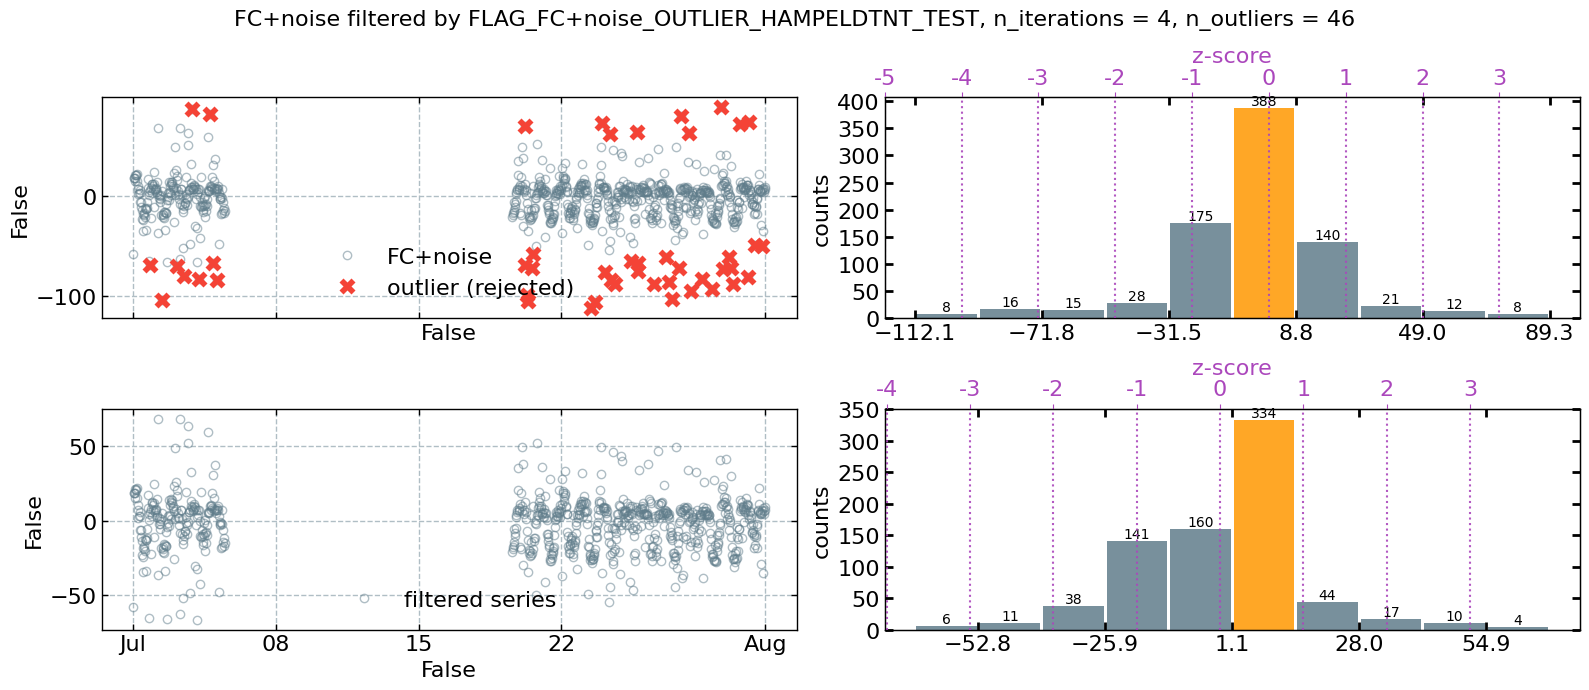

In [35]:
ham = HampelDaytimeNighttime(
    series=s_noise,
    n_sigma_dt=4.5,
    window_length=48 * 13,
    use_differencing=False,
    separate_day_night=False,
    showplot=True,
    verbose=True
)
ham.calc(repeat=True)

In [36]:
# Get flag
flag = ham.get_flag()
flag

TIMESTAMP_MIDDLE
2021-07-01 00:15:00    0.0
2021-07-01 00:45:00    0.0
2021-07-01 01:15:00    0.0
2021-07-01 01:45:00    0.0
2021-07-01 02:15:00    0.0
                      ... 
2021-07-31 21:45:00    0.0
2021-07-31 22:15:00    0.0
2021-07-31 22:45:00    0.0
2021-07-31 23:15:00    0.0
2021-07-31 23:45:00    0.0
Freq: 30min, Name: FLAG_FC+noise_OUTLIER_HAMPELDTNT_TEST, Length: 1488, dtype: float64

In [37]:
# Combine the original series, series+noise and the outlier flag
frame = {'s': s, 's_noise': s_noise, 'flag': flag}
checkdf = pd.DataFrame.from_dict(frame)
checkdf

,s,s_noise,flag
TIMESTAMP_MIDDLE,,,
2021-07-01 00:15:00,20.97900,-57.688935,0.0
2021-07-01 00:45:00,18.49270,18.492700,0.0
2021-07-01 01:15:00,18.42820,18.428200,0.0
2021-07-01 01:45:00,15.42470,15.424700,0.0
2021-07-01 02:15:00,18.50180,18.501800,0.0
...,...,...,...
2021-07-31 21:45:00,8.66570,-34.866478,0.0
2021-07-31 22:15:00,4.51717,4.517170,0.0
2021-07-31 22:45:00,6.42054,6.420540,0.0


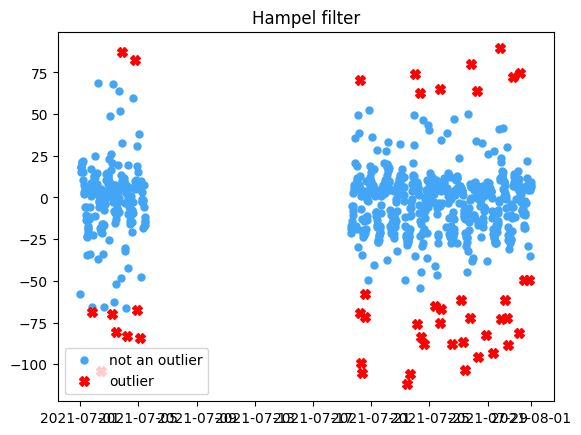

In [38]:
good_data = checkdf.loc[checkdf['flag'] == 0]['s_noise']
rejected_data = checkdf.loc[checkdf['flag'] == 2]['s_noise']

fig, ax = plt.subplots()
ax.plot(good_data, color="#42A5F5", label="not an outlier", lw=0, ms=5, marker="o")
ax.plot(rejected_data, color="red", label="outlier", lw=0, ms=7, marker="X")
plt.title("Hampel filter")
plt.legend()
plt.show()

</br>

# End of notebook

In [39]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-01-13 10:01:47
